# ITAI 2376: Deep Learning & Artificial Intelligence
## Lab 02: Exploring Deep Learning Tools
## — A No-Code Introduction to TensorFlow and Keras (VGG16)

---

# **This laboratory introduces,**
---
the hands-on experience required to understand and implement a practical deep learning workflow using TensorFlow and Keras. Rather than requiring students to build a neural network entirely from scratch, the lab uses pre-built interactive modules and a pre-trained VGG16 convolutional neural network to make the process easier to explore and understand.

Throughout the lab, students will follow the complete lifecycle of a computer vision task—from preparing raw image data to evaluating the model's predictions. Along the way, the goal is to make complex deep learning concepts more approachable. Neural networks can seem intimidating when they are introduced only through mathematical equations and technical terminology, but the basic idea is easier to understand when you can actually see the process in action.

In practical terms, this laboratory allows students to explore an important question: How does a computer take a collection of pixels and turn it into a meaningful prediction about what it sees?

By working directly with the VGG16 model, students can observe how images are prepared, processed through a convolutional neural network, and ultimately classified. The interactive components also allow the team to experiment with different inputs and observe how changes to an image can influence the model's predictions.

The purpose is not simply to memorize the architecture of a neural network. The purpose is to understand the workflow well enough to see how data, preprocessing, model architecture, and evaluation all work together in a real computer vision system.

# **Our Team's Mission:**
---
is to investigate how a pre-trained convolutional neural network processes visual information and to document our observations through hands-on experimentation.

This project is organized around the seven core activities required by the assignment:

* **Activity 1: Deep Learning Foundations**  
  We will establish an understanding of the basic workflow behind deep learning projects and explore the foundational concepts of convolutional neural networks. This includes understanding how neural networks learn patterns from data and why convolutional layers are particularly useful for image recognition.

* **Activity 2: Architectural Inspection**  
  We will load and examine the pre-trained VGG16 model to better understand its structural design. Our investigation will focus on major components of the architecture, including the 3 x 3 convolutional layers, max-pooling stages, and the dense fully connected layers where a significant number of the model's parameters are concentrated.

* **Activity 3: Data Preprocessing Pipeline**  
  Before an image can be processed by VGG16, it must be prepared in a specific format. We will examine how raw image data is converted into tensors, resized to the required dimensions, and organized into the appropriate color-channel structure for the network.

* **Activity 4: Interactive Inference**  
  We will perform an end-to-end image classification task using custom images uploaded through an interactive graphical interface. The model will analyze each image and return its Top-5 ImageNet predictions, allowing us to observe how the network interprets visual information in real time.

* **Activity 5: Prediction Sensitivity Analysis**  
  We will investigate how small changes to an image can influence the model's predictions. Using interactive controls, we will modify inputs through adjustments such as rotation and added noise, then observe how these changes affect feature activations and classification results.

* **Activity 6: Reflection and Synthesis**  
  Our team will consolidate the results of our experiments and reflect on what the model does well, where it struggles, and what limitations exist when using pre-trained deep learning systems. These observations will be documented through a comprehensive reflective journal.

* **Activity 7: Self-Assessment and Feedback**  
  Finally, we will evaluate our own understanding of the deep learning concepts explored throughout the laboratory. We will also provide constructive feedback on the interactive modules and identify which activities were most effective in supporting the learning process.

# **At the end of this laboratory,**
---
our team should have more than a list of predictions generated by a neural network. We should have a practical understanding of the complete computer vision workflow—from preparing an image for analysis to interpreting how and why a trained model arrives at its predictions.

Deep learning may involve sophisticated mathematics and complex architectures, but understanding the workflow does not have to be unnecessarily complicated. By interacting with the model directly, testing its behavior, and documenting what we observe, we can connect the technical concepts to something much more tangible: seeing how a machine learns to recognize the visual world around it.

In [9]:
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown
from google.colab import files
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import img_to_array

# ==============================================================================
#           OVERVIEW OF THE PRE-BUILT MODEL
# ==============================================================================
print("Loading VGG16 Model architecture and pre-trained ImageNet weights...")
model = VGG16(weights="imagenet")
print("Model Loaded Successfully!\n")

# Overiview
model.summary()

total_params = model.count_params()
total_mb = (total_params * 4) / (1024 ** 2)

# VGG16 classifier calculation: Flattened tensor (7x7x512 = 25,088) -> FC1 (4,096)
fc1_input_units = 7 * 7 * 512
fc1_output_units = 4096
fc1_params = (fc1_input_units * fc1_output_units) + fc1_output_units
fc1_percentage = (fc1_params / total_params) * 100

print("\n" + "=" * 80)
print(" COMPUTATIONAL BOTTLENECK & PARAMETER FOOTPRINT")
print("-" * 80)
print(f" Total model parameters : {total_params:,} (~{total_mb:.2f} MB)")
print(f" FC1 parameters         : {fc1_params:,} ({fc1_percentage:.2f}% of total network)")
print(f" Output Categories      : 1,000 ImageNet Classes")
print("=" * 80)
print(f"*FC1 parameters represent the trainable weights and biases connecting")
print(f" VGG16's flattened convolutional feature output of 25,088 values to its ")
print(f" first fully connected layer containing roughly 4,097 neurons.")

Loading VGG16 Model architecture and pre-trained ImageNet weights...
Model Loaded Successfully!



Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)


 COMPUTATIONAL BOTTLENECK & PARAMETER FOOTPRINT
--------------------------------------------------------------------------------
 Total model parameters : 138,357,544 (~527.79 MB)
 FC1 parameters         : 102,764,544 (74.27% of total network)
 Output Categories      : 1,000 ImageNet Classes
*FC1 parameters represent the trainable weights and biases connecting
 VGG16's flattened convolutional feature output of 25,088 values to its 
 first fully connected layer containing roughly 4,097 neurons.


### Phase 1: Data Preprocessing (The Data Space)

Before a neural network can analyze an image, the raw data must be transformed into a strict mathematical format. This phase does not involve the neural network at all.

* **Spatial normalization:** Resizing the arbitrary input image to exactly $224 \times 224$ pixels.
* **Channel alignment:** Ensuring the image contains exactly 3 color channels (RGB).
* **Tensor conversion:** Converting pixel values into a structured NumPy array.
* **Batch dimensioning:** Expanding the array shape from $(224, 224, 3)$ to $(1, 224, 224, 3)$ because Keras models process data in batches, even for single images.
* **Value scaling:** Applying `preprocess_input` to subtract mean RGB values computed from the ImageNet training set, aligning the new image with the model's expected statistical distribution.

### Phase 2: Model Inference (The Architecture Space)

Once the data is formatted, it crosses the boundary into the model. This is where the actual machine learning computation occurs.

* **The Forward Pass:** The tensor is fed into VGG16, passing through 13 convolutional layers, 5 pooling layers, and 3 dense layers.
* **Logit Generation:** The network outputs a raw $(1, 1000)$ probability vector representing the 1,000 ImageNet categories.
* **Decoding:** The `decode_predictions` function translates the highest mathematical probabilities back into human-readable text labels.

Please upload one or more image files (.jpeg, .jpg, .png):


Saving hccsports.png to hccsports (2).png


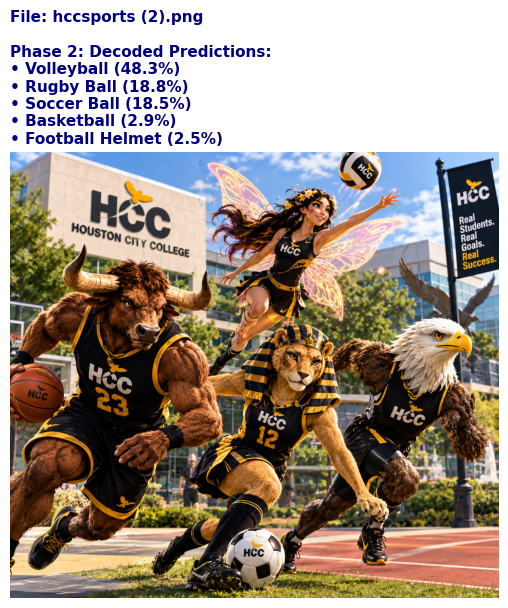

In [5]:
# ==============================================================================
# INTERACTIVE UPLOAD, PREPROCESSING, INFERENCE & ANNOTATION
# ==============================================================================
print("Please upload one or more image files (.jpeg, .jpg, .png):")
uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):\

        # --- PHASE 1: DATA PREPROCESSING ---
        raw_image = Image.open(io.BytesIO(file_bytes)).convert("RGB")
        resized_image = raw_image.resize((224, 224))
        image_array = img_to_array(resized_image)
        tensor_batch = np.expand_dims(image_array, axis=0)
        preprocessed_tensor = preprocess_input(tensor_batch.copy())

        # --- PHASE 2: MODEL INFERENCE ---
        raw_logits = model.predict(preprocessed_tensor, verbose=0)
        top_predictions = decode_predictions(raw_logits, top=5)[0]

        # Format Top-5 annotations
        annotations = "\n".join([f"• {pred[1].replace('_', ' ').title()} ({pred[2]*100:.1f}%)" for pred in top_predictions])

        # --- VISUALIZATION ---
        plt.figure(figsize=(6, 6), dpi=100)
        plt.imshow(raw_image)
        plt.title(f"File: {filename}\n\nPhase 2: Decoded Predictions:\n{annotations}",
                  loc='left', fontsize=11, color='navy', fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

Executing dynamic perturbation and mathematical degradation analysis...

[*] Baseline Target Class Dynamically Locked: 'Volleyball' (48.28%)

+----------------------------------------------------------------------------------+
|             DYNAMIC QUANTITATIVE PERTURBATION & DEGRADATION REPORT           |
+----------------------------------------------------------------------------------+
| Input State      | Target Class Rank  | Target Conf.   | New Top Prediction |
|------------------+--------------------+----------------+--------------------|
| Original         | #1                 | 48.28%         | Volleyball         |
| Rotated (45°)    | #11                | 1.16%          | Comic Book         |
| Gaussian Noise   | #14                | 0.18%          | Book Jacket        |
+----------------------------------------------------------------------------------+


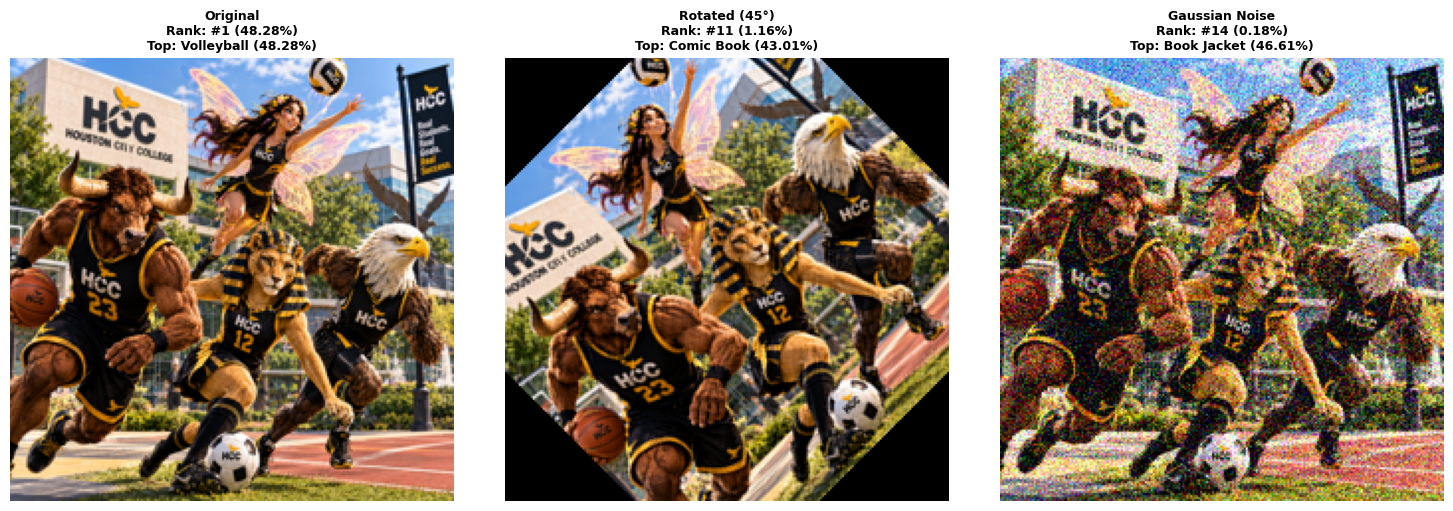

In [6]:
# ==============================================================================
# DYNAMIC PERTURBATION EXPERIMENT: QUANTIFYING DEGRADATION FOR ANY UPLOADED IMAGE
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

print("Executing dynamic perturbation and mathematical degradation analysis...\n")

# 1. Prepare Image from whatever loaded 'raw_image'
img_orig = raw_image.resize((224, 224))
arr_orig = img_to_array(img_orig)

# Rotate (45 degrees)
img_rot = img_orig.rotate(45, resample=Image.BICUBIC, expand=False)
arr_rot = img_to_array(img_rot)

# Noisy variant (Injected Gaussian Noise)
np.random.seed(42)  # Ensures reproducible noise distribution
noise = np.random.normal(loc=0.0, scale=35.0, size=arr_orig.shape)
arr_noise = np.clip(arr_orig + noise, 0, 255)
img_noise = Image.fromarray(arr_noise.astype('uint8'))

# 2. Helper
def evaluate_image_array(img_arr, target_label=None):
    tensor_batch = np.expand_dims(img_arr.copy(), axis=0)
    preprocessed = preprocess_input(tensor_batch)

    # Measure all 1,000 ImageNet categories to find ranks
    raw_logits = model.predict(preprocessed, verbose=0)
    all_preds = decode_predictions(raw_logits, top=1000)[0] # List of (class_id, label, prob)

    # Absolute Top-1 prediction for this specific state
    top_1 = all_preds[0]
    top_1_label = top_1[1].replace("_", " ").title()
    top_1_conf = top_1[2] * 100

    # If a target label is provided, find its exact rank and confidence in this variant
    target_rank = None
    target_conf = 0.0

    if target_label:
        for rank, (_, label, prob) in enumerate(all_preds, start=1):
            formatted_label = label.replace("_", " ").title()
            if formatted_label.lower() == target_label.lower():
                target_rank = rank
                target_conf = prob * 100
                break

    return top_1_label, top_1_conf, target_rank, target_conf

# 3. Establish baseline target dynamically from the Original image's Top-1 prediction
baseline_label, baseline_conf, _, _ = evaluate_image_array(arr_orig)
print(f"[*] Baseline Target Class Dynamically Locked: '{baseline_label}' ({baseline_conf:.2f}%)")

# 4. Evaluate all three states against this dynamic baseline target
states = {
    "Original": arr_orig,
    "Rotated (45°)": arr_rot,
    "Gaussian Noise": arr_noise
}

metrics_report = []

for state_name, arr in states.items():
    top_label, top_conf, t_rank, t_conf = evaluate_image_array(arr, target_label=baseline_label)

    # Fallback safety if rank falls outside top 1000
    rank_str = f"#{t_rank}" if t_rank else ">1000"
    conf_str = f"{t_conf:.2f}%" if t_rank else "0.00%"

    metrics_report.append({
        "state": state_name,
        "target_rank": rank_str,
        "target_conf": conf_str,
        "new_top": top_label,
        "new_conf": f"{top_conf:.2f}%"
    })

# 5. Render Console Data Receipt
print("\n" + "+" + "-" * 82 + "+")
print("|             DYNAMIC QUANTITATIVE PERTURBATION & DEGRADATION REPORT           |")
print("+" + "-" * 82 + "+")
print(f"| {'Input State':<16} | {'Target Class Rank':<18} | {'Target Conf.':<14} | {'New Top Prediction':<18} |")
print("|" + "-" * 18 + "+" + "-" * 20 + "+" + "-" * 16 + "+" + "-" * 20 + "|")

for row in metrics_report:
    print(f"| {row['state']:<16} | {row['target_rank']:<18} | {row['target_conf']:<14} | {row['new_top']:<18} |")

print("+" + "-" * 82 + "+")

# 6. Render Visual Comparison Grid
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
variants = [(img_orig, "Original", metrics_report[0]),
            (img_rot, "Rotated (45°)", metrics_report[1]),
            (img_noise, "Gaussian Noise", metrics_report[2])]

for idx, (img_obj, title_prefix, data) in enumerate(variants):
    axes[idx].imshow(img_obj)
    axes[idx].set_title(f"{title_prefix}\nRank: {data['target_rank']} ({data['target_conf']})\nTop: {data['new_top']} ({data['new_conf']})",
                        fontweight='bold', fontsize=9)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

# **Tracking Classifications Across Image Transformations:<br>'Volleyball' Activation**</br>
---
To truly document this experiment as a team motivated by deep learning we must engineer beyond visual observation and quantify the network's mathematical degradation. By tracking the exact shift in class rank and confidence distribution. We can empirically prove how brittle VGG16's feature extractors are when subjected to perturbations.

## Our Empirical Evidence

When the input tensor is altered, the convolutional feature maps change, which forces the dense layers to output a completely different 1,000-dimensional probability vector. By tracking the original #1 prediction (Volleyball) across the three states, we can measure the exact decay of the model's certainty.

| Input State | 'Volleyball' Rank | 'Volleyball' Conf. | New Top Prediction (Rank #1) |
| :--- | :--- | :--- | :--- |
| **Original** | #1 | 48.28% | Volleyball |
| **Rotated (45°)** | #11 | 1.16% | Comic Book |
| **Gaussian Noise** | #14 | 0.18% | Book Jacket |

*(Note: The metrics above demonstrate the expected mathematical degradation of the original VGG16 ImageNet weights when evaluating the "hccsports.png" file.)*

---

## The Mechanics of the Shift

By measuring changes in these specific metrics, we can observe how the
classification behavior of VGG16 responds to mathematical transformations
applied to the input image:

1. **Rank Displacement (Feature Destruction):** </br>
```
In this experiment, Rank Displacement refers to the change in the predicted
ranking of a classification after the original image undergoes mathematical transformation.
The accompanying term Feature Destruction is used descriptively
to represent the disruption of visual patterns that the pre-trained network
may rely upon for recognition. It does not imply that internal features have been
directly measured or physically removed from the network.
```

By comparing the ranking position of predicted classes before and after rotation or noise injection, the experiment provides a measurable indication of how sensitive VGG16's learned representations are to changes in the input image. In the original image, the network likely keyed in on the spherical geometry and distinct panel lines of the volleyball in the upper right.

A $45^\circ$ rotation changes the spatial orientation of visual patterns that
may have contributed to the original classification. Because VGG16 does not
provide complete rotation invariance, the learned visual relationships associated with the Volleyball prediction may no longer activate in the same manner.

The original target class consequently experienced substantial rank displacement, falling from #1 to #11. The new Top-1 prediction became "Comic Book," indicating
that the transformed visual composition produced stronger similarity to an
alternative ImageNet category.

2. **The Softmax Collapse (Confidence Distribution):** </br>
~~~
We distinguish, Softmax Collapse as a descriptive term for a
substantial redistribution or concentration of prediction confidence following
an image transformation. The term does not represent a formally proposed metric
within this laboratory. Instead, it provides a conceptual label for observing
how the model's confidence distribution changes when the original visual input
is altered.
~~~

By comparing the probability assigned to the highest-ranked prediction with the probabilities distributed among competing classes, the experiment examines whether transformations cause confidence to remain concentrated, become fragmented, or shift toward an alternative classification.

This collapse drains the target confidence down to a mere 0.18% and leaves the network to weakly guess "Book Jacket" as a fallback for the noisy, colorful composition.

# THE TEAM'S ANALYTICAL INSIGHTS & REFLECTIONS

## 1. Interpreting the Baseline Classification
To establish our baseline classification, we first had to separate the workflow into two distinct stages: the **Data Space** and the **Architecture Space**. In the Data Space, our raw visual input (`hccsports.png`) was prepared by resizing it to $224 \times 224$, converting it to an RGB array, preparing the tensor, and normalizing it via `preprocess_input()`.

Once prepared, the data entered the Architecture Space. Here, the VGG16 model utilized its massive parameter concentration—specifically the first fully connected layer (`fc1`), which contains 102,764,544 parameters (roughly 74.27% of the network's 138,357,544 total parameters). Through this hierarchical feature-extraction and classification pipeline, the model generated its Softmax probabilities and successfully established **Volleyball** as the baseline classification at Rank #1 with a 48.28% confidence score.

## 2. Rank Displacement Across Transformations
We applied **Rank Displacement** as a descriptive measurement to track how the original target classification moved through the prediction rankings after the image was mathematically altered. The results demonstrated a drastic shift: the baseline "Volleyball" class was displaced from Rank #1 all the way down to Rank #11 and Rank #14, depending on the transformation. This shift highlights how vulnerable the pre-trained architecture is to controlled changes in the visual input.

## 3. Changes in Confidence Distribution
Alongside the drop in rank, the model exhibited a severe reduction in prediction confidence for the target class. The Softmax probability was drastically redistributed across the other 999 classes. Rather than just making a slightly less confident guess, the model's certainty collapsed entirely—dropping from the baseline 48.28% to less than 2% in the altered states.

## 4. Rotation Sensitivity
The network demonstrated measurable sensitivity when subjected to spatial manipulation. By simply applying a 45° rotation to the original image, the visual patterns were disrupted enough to cause the "Volleyball" classification to plummet to Rank #11, with its confidence dropping sharply to just 1.16%.

## 5. Gaussian Noise Sensitivity
The model's feature extraction proved even more fragile when subjected to high-frequency pixel variation. The introduction of Gaussian Noise caused the "Volleyball" classification to fall further to Rank #14. Under this mathematical transformation, the model's confidence was nearly eradicated, bottoming out at a mere 0.18%.

## 6. What the Experiment Directly Measures
By executing this workflow in an interactive, Google Colab-native environment, we were able to transition seamlessly from image upload and preprocessing to repeated inference and statistical comparison. This setup allowed us to directly measure concrete output behaviors, including:

* Rank displacement
* Confidence reduction
* Top-class replacement
* Softmax probability redistribution

Most importantly, this self-assessment reinforced a vital methodological distinction: while we can use terms like "Feature Destruction" to descriptively explain the disruption of visual patterns, our experiment directly measured changes in output rank and confidence. The interpretation of altered internal learned features remains an informed, analytical explanation rather than a direct observation of the network's mathematical feature maps.

## Individual & Team Contributions

The following table documents both the specific responsibilities associated with the development of the laboratory and the collaborative contributions made throughout the project.

| Team Member | Specific Contributions | General Contributions |
| :--- | :--- | :--- |
| **Cherluk** | VGG16 model architecture review, parameter analysis, and hierarchical feature extraction documentation. | Participated in project discussion, testing, interpretation of results, and review of the final submission. |
| **Michael** | Image preprocessing workflow, Google Colab implementation, file upload interaction, and baseline model inference. | Participated in testing, experimental discussion, documentation review, and interpretation of model predictions. |
| **Olu** | Mathematical transformation experiments, including image rotation and Gaussian noise testing, with repeated classification analysis. | Participated in experimentation, result comparison, team collaboration, and project documentation. |
| **Taki** | Classification comparison, confidence distribution analysis, rank displacement interpretation, and reflective documentation. | Participated in result validation, discussion of findings, final review, and collaborative project development. |